# Exploratory Data Analysis on BESTIE-CW-26

## 0. Setup & Imports


These commands set up a Python environment for natural language processing (NLP), data analysis, and visualization. The `pip install` line installs key libraries: **datasets** (for accessing benchmark datasets), **spaCy** (advanced NLP), **seaborn** and **matplotlib** (visualization), **scikit-learn** (machine learning), **pandas** (data manipulation), **wordcloud** (text visualization), and **textblob** (simple NLP tasks like sentiment analysis). The second command downloads the **`en_core_web_sm`** model for spaCy, which provides tokenization, POS tagging, and named entity recognition. The final command downloads required linguistic corpora for TextBlob, enabling features like sentiment analysis and part-of-speech tagging.

In [118]:
%pip install datasets spacy seaborn scikit-learn pandas matplotlib wordcloud textblob --quiet

%load_ext autoreload
%autoreload 2


!python -m spacy download en_core_web_sm -q
!python -m textblob.download_corpora

Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\MIS\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MIS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MIS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\MIS\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\MIS\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\MIS\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-d

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset

This following block configures analysis environment and initializes NLP tools. `sns.set_theme(style='whitegrid', font_scale=1.1)` sets a clean Seaborn plotting style with slightly larger text for readability. `PALETTE` defines custom colors for different English varieties to keep visualizations consistent. `FIG_DIR` specifies a folder to save figures, and `os.makedirs(..., exist_ok=True)` ensures that folder exists (creating it if needed). `spacy.load('en_core_web_sm', disable=['ner'])` loads spaCy’s English model but disables named entity recognition to make processing faster when you don’t need it.

In [120]:
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'en-AU': "#4F4CB0", 'en-IN': '#DD8452', 'en-UK': '#55A868'}
FIG_DIR = './figures'
import os; os.makedirs(FIG_DIR, exist_ok=True)

nlp = spacy.load('en_core_web_sm', disable=['ner'])
print('spaCy version:', spacy.__version__)

spaCy version: 3.8.13


## 1. BESTIE-CW-26 Dataset Loading & Overview

This code loads the **BESSTIE-CW-26** dataset and prepares it as a single Pandas DataFrame for analysis. `load_dataset(...)` fetches the dataset (which typically contains splits like train, validation, and test). The loop converts each split into a Pandas DataFrame, adds a new column (`split`) to keep track of where each row came from, and stores them in a list. `pd.concat(...)` then merges all splits into one unified DataFrame. Finally, it prints the column names and total number of rows, and displays the first 3 entries to give a quick preview of the data.

In [121]:
dataset = load_dataset('surrey-nlp/BESSTIE-CW-26')

dfs = []
for split_name, split_data in dataset.items():
    df_split = split_data.to_pandas()
    df_split['split'] = split_name
    dfs.append(df_split)
df = pd.concat(dfs, ignore_index=True)

print('Columns:', df.columns.tolist())
print('Total rows:', len(df))
df.head(3)

Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm', 'split']
Total rows: 6243


,text,variety,source,Sentiment,Sarcasm,split
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0,train
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0,train
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0,train


In [122]:
TEXT_COL      = 'text'        
VARIETY_COL   = 'variety'     
SOURCE_COL    = 'source'      
SENTIMENT_COL = 'Sentiment'   
SARCASM_COL   = 'Sarcasm'

print(df[[VARIETY_COL, SOURCE_COL, SENTIMENT_COL, SARCASM_COL]].value_counts())

variety  source  Sentiment  Sarcasm
en-UK    Google  1.0        0.0        955
en-IN    Google  1.0        0.0        886
         Reddit  0.0        0.0        736
en-AU    Reddit  0.0        1.0        500
         Google  1.0        0.0        490
en-UK    Reddit  0.0        0.0        489
en-AU    Reddit  1.0        0.0        368
                 0.0        0.0        351
en-UK    Google  0.0        0.0        331
en-IN    Google  0.0        0.0        288
         Reddit  1.0        0.0        263
en-UK    Reddit  0.0        1.0        150
en-IN    Reddit  0.0        1.0        150
en-AU    Google  0.0        0.0        137
en-UK    Reddit  1.0        0.0         76
en-AU    Google  0.0        1.0         42
         Reddit  1.0        1.0         16
en-IN    Google  0.0        1.0          9
en-AU    Google  1.0        1.0          3
en-UK    Reddit  1.0        1.0          2
         Google  0.0        1.0          1
Name: count, dtype: int64


This block shows how the dataset is distributed across different categories. It first extracts the unique values of **varieties** (For example, en-IN, en-UK, en-AU) and **sources** (Google, Reddit). Then, it creates separate DataFrames for each variety, sarcasm label, and sentiment label using dictionary comprehensions—making it easier to analyze each group independently later.

The printed outputs show that the dataset is fairly balanced across varieties and sources, with slightly more samples from en-IN and Google. However, there is a **significant class imbalance in sarcasm**, where non-sarcastic samples (5370) heavily outnumber sarcastic ones (873), which could affect model performance. On the other hand, the **sentiment distribution is relatively balanced** between the two classes, making it less problematic for training models.


In [123]:
varieties = df[VARIETY_COL].unique()
sources = df[SOURCE_COL].unique()

var_dfs = {var: df[df[VARIETY_COL] == var] for var in varieties}
sarcasm_dfs = {label: df[df[SARCASM_COL] == label] for label in df[SARCASM_COL].unique()}
sentiment_dfs = {label: df[df[SENTIMENT_COL] == label] for label in df[SENTIMENT_COL].unique()}

print("Variety distribution:\n", df[VARIETY_COL].value_counts())
print("\nSource distribution:\n", df[SOURCE_COL].value_counts())
print("\nSarcasm distribution:\n", df[SARCASM_COL].value_counts())
print("\nSentiment distribution:\n", df[SENTIMENT_COL].value_counts())

Variety distribution:
 variety
en-IN    2332
en-UK    2004
en-AU    1907
Name: count, dtype: int64

Source distribution:
 source
Google    3142
Reddit    3101
Name: count, dtype: int64

Sarcasm distribution:
 Sarcasm
0.0    5370
1.0     873
Name: count, dtype: int64

Sentiment distribution:
 Sentiment
0.0    3184
1.0    3059
Name: count, dtype: int64


## 1.1 Label Distribution Visualization

### Overall Distribution of Sarcasm and Sentiment

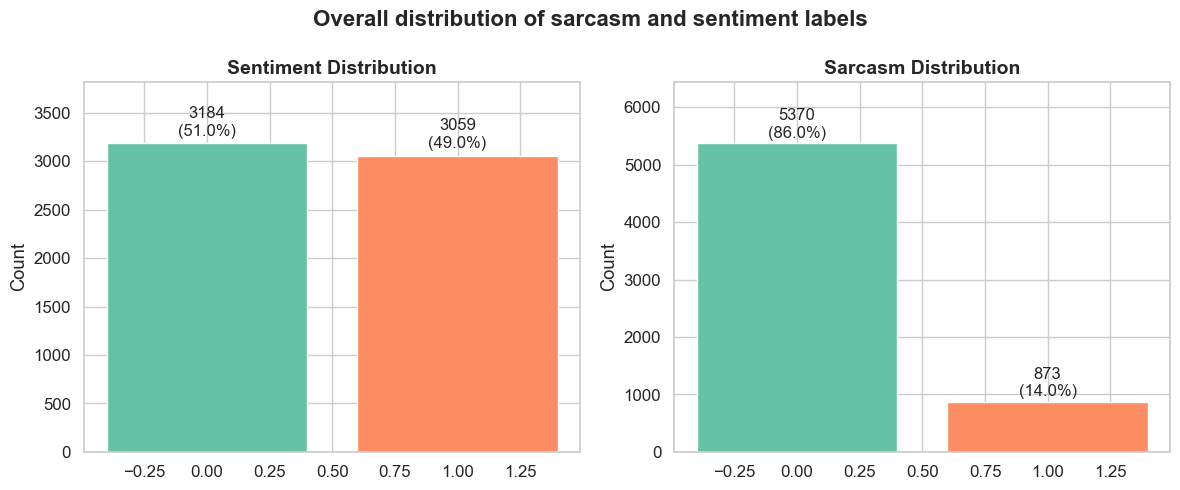

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, [SENTIMENT_COL, SARCASM_COL], ['Sentiment Distribution', 'Sarcasm Distribution']):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', n_colors=len(counts)))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

    for bar, val in zip(bars, counts.values):
        in_percent = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, f'{val}\n({in_percent:.1f}%)', ha='center', va='bottom', fontsize=12)
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.suptitle('Overall distribution of sarcasm and sentiment labels', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'label_distribution.png'))
plt.show()

### Sentiment & Sarcasm Distribution per Variety

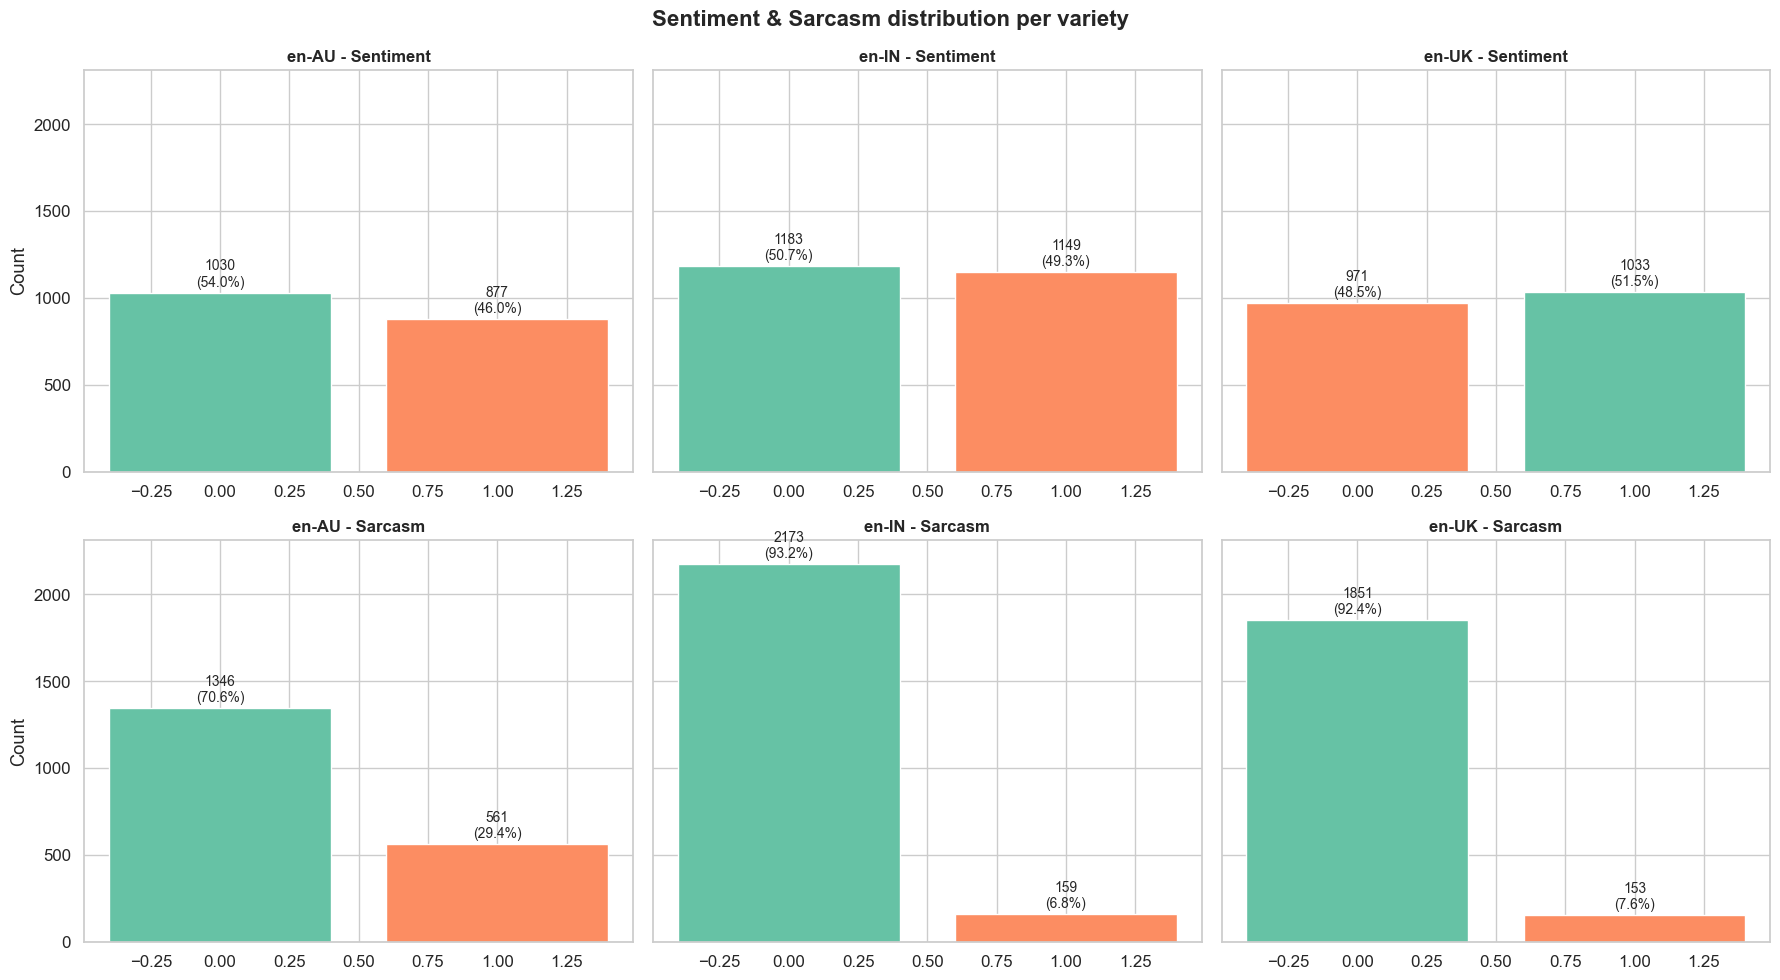

In [125]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

row_labels = ['Sentiment', 'Sarcasm']
col_labels = ['en-AU', 'en-IN', 'en-UK']
for i, row_label in enumerate(row_labels):
    for j, col_label in enumerate(col_labels):
        ax = axes[i, j]
        subset = df[df[VARIETY_COL] == col_label]
        if row_label == 'Sentiment':
            counts = subset[SENTIMENT_COL].value_counts()
            title = f'{col_label} - Sentiment'
        else:
            counts = subset[SARCASM_COL].value_counts()
            title = f'{col_label} - Sarcasm'
        
        bars = ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', n_colors=len(counts)))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        if j == 0:
            ax.set_ylabel('Count')
        
        for bar, val in zip(bars, counts.values):
            in_percent = val / len(subset) * 100
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, f'{val}\n({in_percent:.1f}%)', ha='center', va='bottom', fontsize=10)
        ax.set_ylim(0, max(counts.values) * 1.25)

plt.suptitle('Sentiment & Sarcasm distribution per variety', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'label_distribution_by_variety.png'))
plt.show()

In [126]:
def plot_pos_distribution(df, variety, ax, label_col=None, label_val=None, pos_tags=None):
    if pos_tags is None:
        pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'ADP', 'DET']

    subset = df[df[VARIETY_COL] == variety]
    if label_col is not None and label_val is not None:
        subset = subset[subset[label_col] == label_val]

    pos_counts = Counter()
    for doc in nlp.pipe(subset[TEXT_COL], batch_size=50):
        pos_counts.update([token.pos_ for token in doc if token.pos_ in pos_tags])
    
    total = sum(pos_counts.values())
    if total > 0:
        for tag in pos_counts:
            pos_counts[tag] = (pos_counts[tag] / total) * 100
    
    values = [pos_counts.get(tag, 0) for tag in pos_tags]
    
    colors = sns.color_palette('Set2', n_colors=len(pos_tags))
    
    ax.bar(pos_tags, values, color=colors)
    ax.set_xticks(range(len(pos_tags)))
    ax.set_xticklabels(pos_tags, rotation=45)
    ax.set_ylabel("Proportion (%)")

    if label_col is not None:
        if label_col == SARCASM_COL:
            label_name = "Sarcastic" if label_val == 1.0 else "Non-Sarcastic"
        elif label_col == SENTIMENT_COL:
            label_name = "Positive" if label_val == 1.0 else "Negative"
        else:
            label_name = f"{label_val}"

        ax.set_title(f"{variety} - {label_name}")
    else:
        ax.set_title(f"{variety}")

### POS Distribution per Variety

In [127]:
pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'ADP', 'DET']

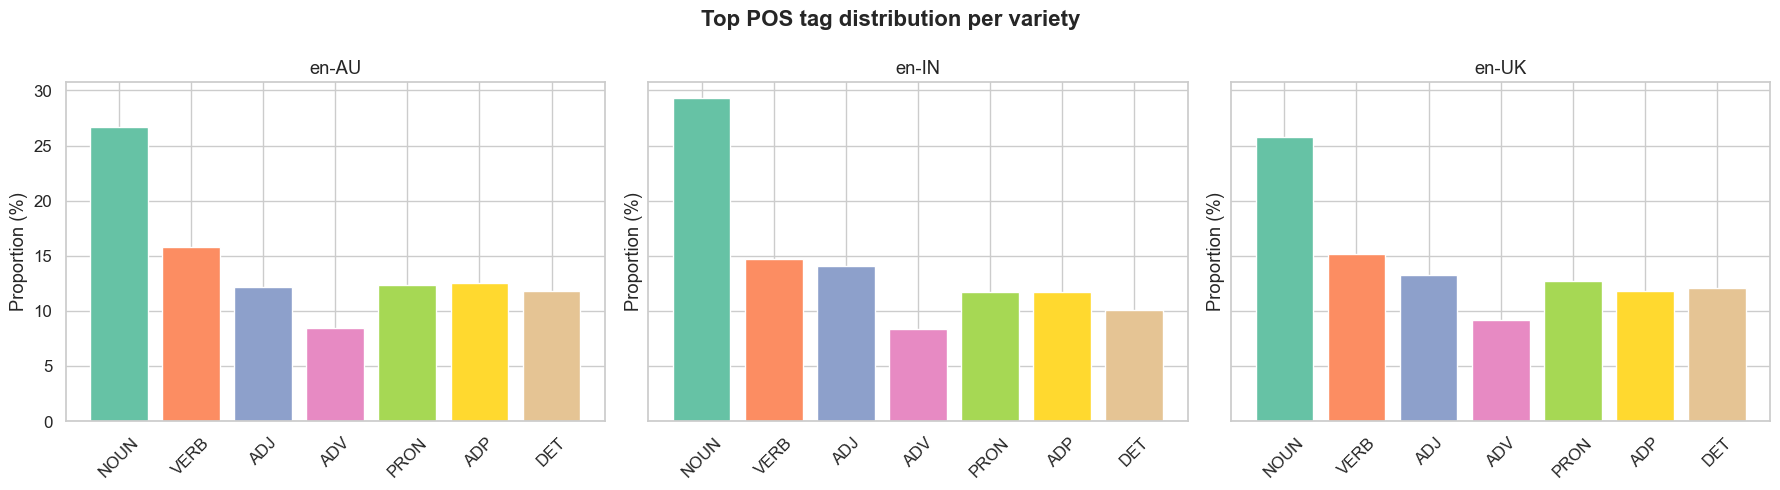

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, variety in zip(axes, col_labels):
    plot_pos_distribution(df, variety, ax, pos_tags=pos_tags)
plt.suptitle('Top POS tag distribution per variety', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pos_distribution_by_variety.png'))
plt.show()

### POS Distribution per Variety Sarcasm and Non-Sarcasm

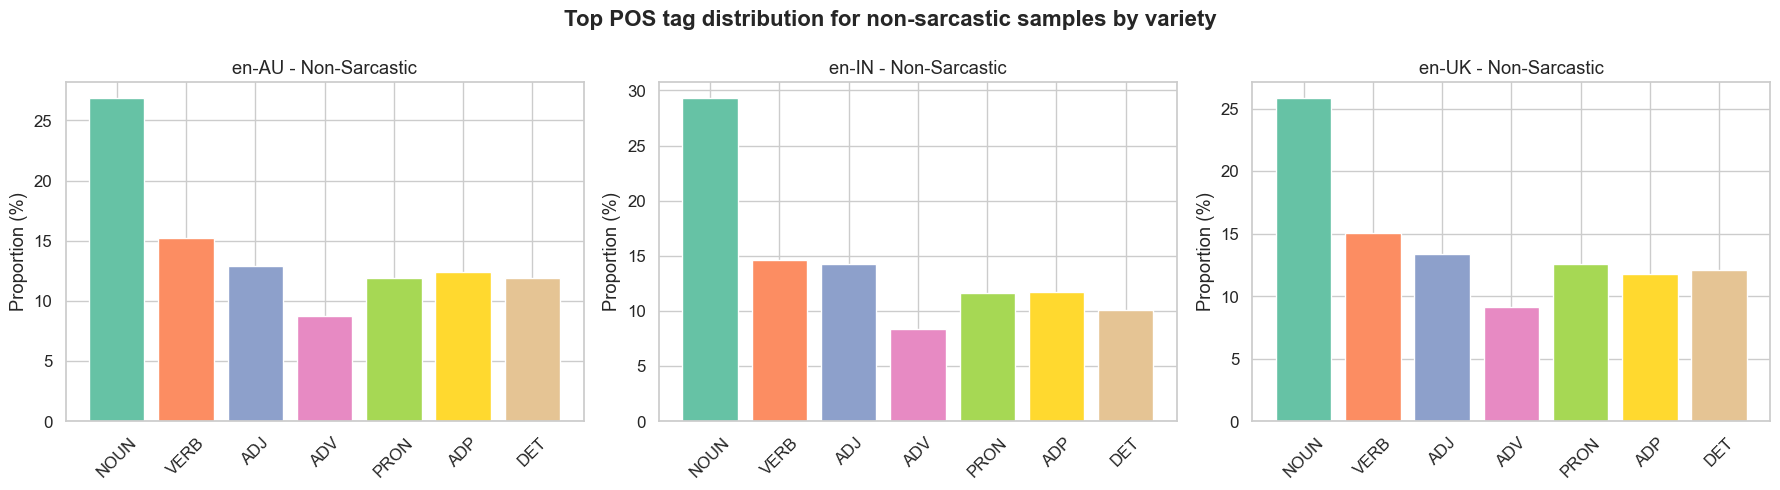

In [129]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, variety in enumerate(col_labels):
    plot_pos_distribution(df, variety, axes[i], label_col=SARCASM_COL, label_val=0.0, pos_tags=pos_tags)
plt.suptitle('Top POS tag distribution for non-sarcastic samples by variety', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pos_distribution_non_sarcastic_by_variety.png'))
plt.show()

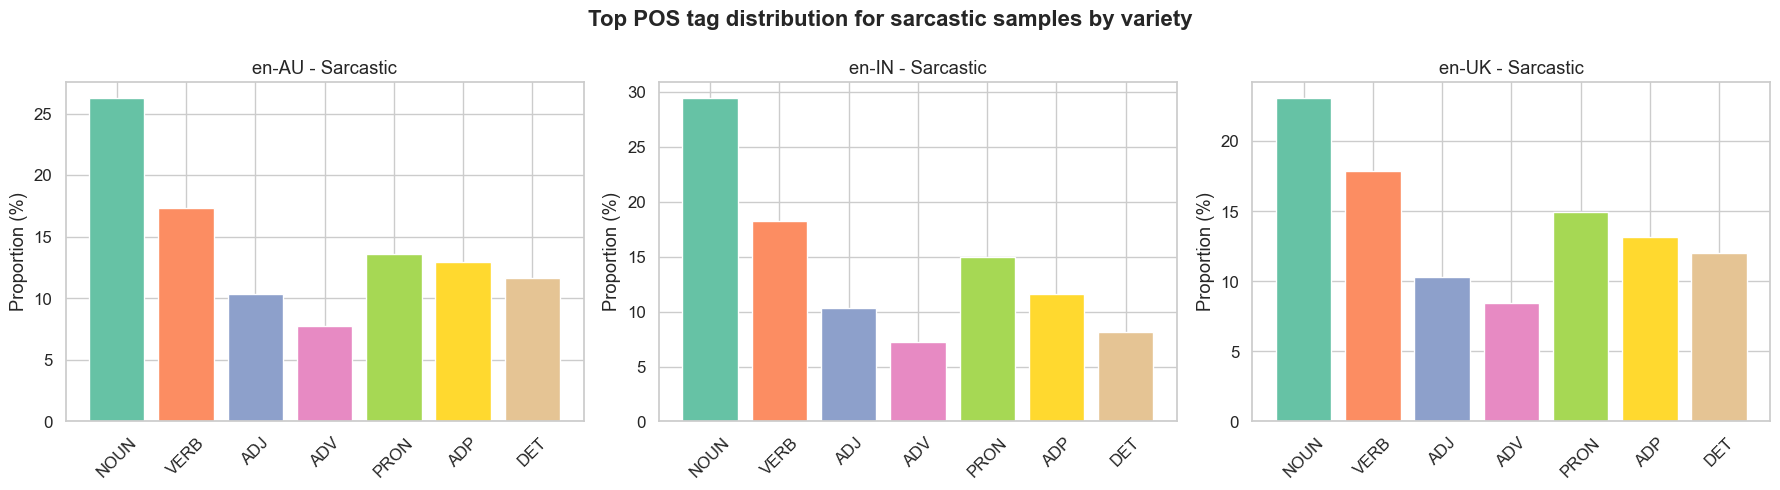

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, variety in enumerate(col_labels):
    plot_pos_distribution(df, variety, axes[i], label_col=SARCASM_COL, label_val=1.0, pos_tags=pos_tags)
plt.suptitle('Top POS tag distribution for sarcastic samples by variety', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pos_distribution_sarcastic_by_variety.png'))
plt.show()

### POS Distribution per Variety Positive and Negative Sentiment

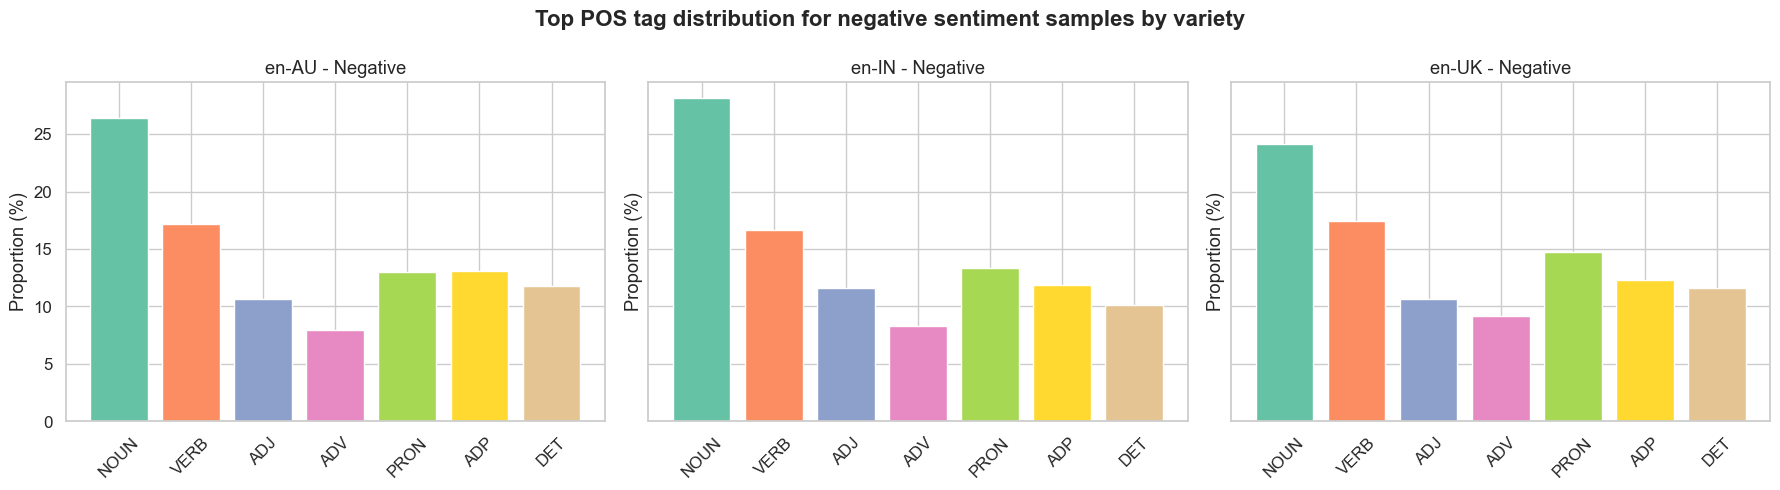

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, variety in enumerate(col_labels):
    plot_pos_distribution(df, variety, axes[i], label_col=SENTIMENT_COL, label_val=0.0, pos_tags=pos_tags)
plt.suptitle('Top POS tag distribution for negative sentiment samples by variety', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pos_distribution_negative_sentiment_by_variety.png'))
plt.show()

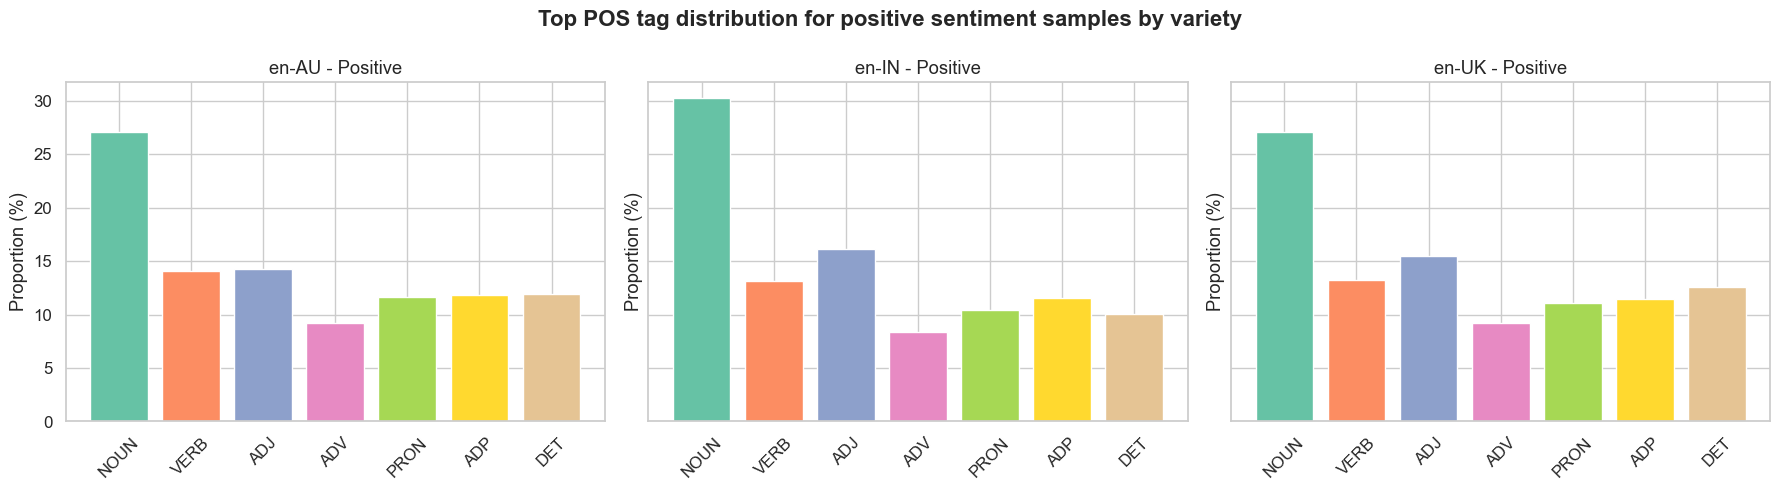

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, variety in enumerate(col_labels):
    plot_pos_distribution(df, variety, axes[i], label_col=SENTIMENT_COL, label_val=1.0, pos_tags=pos_tags)
plt.suptitle('Top POS tag distribution for positive sentiment samples by variety', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pos_distribution_positive_sentiment_by_variety.png'))
plt.show()

## 1.2 Vocabulary Analysis

### Vocabulary Building and Preprocessing (Train Split Only)

In [133]:
from spacy.lang.en.stop_words import STOP_WORDS
print(f"Number of stop words: {len(STOP_WORDS)}")

Number of stop words: 326


In [134]:
def build_vocabulary(texts, nlp, stop_words=None):
    vocab = Counter()
    for doc in nlp.pipe(texts, batch_size=50):
        tokens = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]
        if stop_words is not None:
            tokens = [t for t in tokens if t not in stop_words]
        vocab.update(tokens)
    return vocab

In [135]:
train_df = df[df['split'] == 'train']
train_texts = train_df[TEXT_COL].tolist()
vocabs = {}
for variety in col_labels:
    variety_texts = train_df[train_df[VARIETY_COL] == variety][TEXT_COL].tolist()
    vocab = build_vocabulary(variety_texts, nlp, stop_words=STOP_WORDS)
    vocabs[variety] = vocab

for variety, vocab in vocabs.items():
    print(f"{variety}: {len(vocab)} unique tokens")

en-AU: 6393 unique tokens
en-IN: 5988 unique tokens
en-UK: 5848 unique tokens


### Jaccard Similarity Analysis of Varieties

In [136]:
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0.0

In [137]:
jaccard_matrix = pd.DataFrame(index=col_labels, columns=col_labels, dtype=float)
for var1 in col_labels:
    for var2 in col_labels:
        set1 = set(vocabs[var1].keys())
        set2 = set(vocabs[var2].keys())
        jaccard_matrix.loc[var1, var2] = jaccard_similarity(set1, set2)

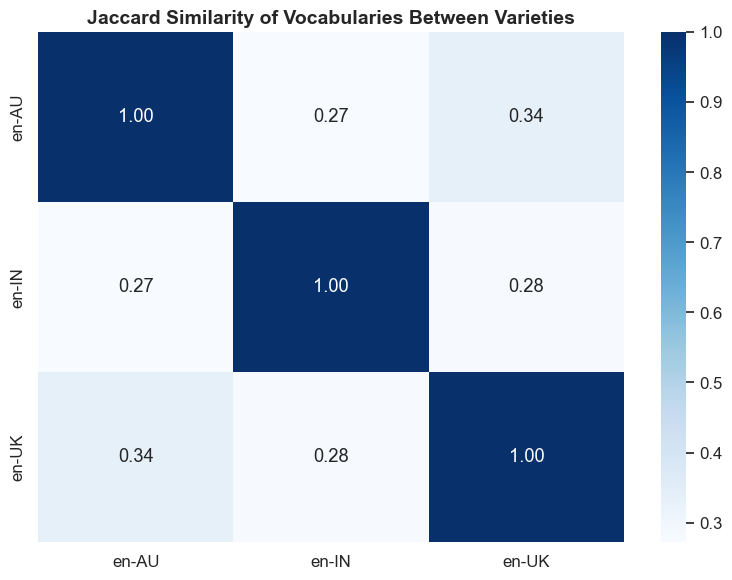

In [138]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap='Blues', cbar=True, ax=ax)
ax.set_title('Jaccard Similarity of Vocabularies Between Varieties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'jaccard_similarity_heatmap.png'))
plt.show()

### TF-IDF Cosine Similarity Analysis of Varieties

In [139]:
variety_texts = {var: train_df[train_df[VARIETY_COL] == var][TEXT_COL].tolist() for var in col_labels}
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

texts_in_order = [' '.join(variety_texts[var]) for var in col_labels]
tfidf_matrix = tfidf_vectorizer.fit_transform(texts_in_order)

cosine_sim_matrix = cosine_similarity(tfidf_matrix)
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=col_labels, columns=col_labels)

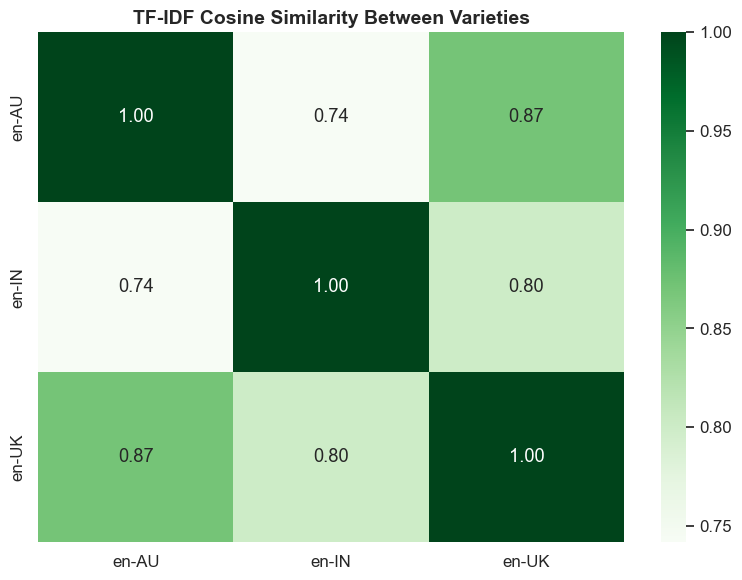

In [140]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cosine_sim_df, annot=True, fmt=".2f", cmap='Greens', cbar=True, ax=ax)
ax.set_title('TF-IDF Cosine Similarity Between Varieties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tfidf_cosine_similarity_heatmap.png'))
plt.show()

### What is Unique to Each Variety?

In [141]:
unique_words = {}
for variety in col_labels:
    variety_vocab = set(vocabs[variety].keys())
    other_varieties = set()
    for other_var in col_labels:
        if other_var != variety:
            other_varieties.update(set(vocabs[other_var].keys()))
    unique_words[variety] = variety_vocab - other_varieties
    print(f"{variety} has {len(unique_words[variety])} unique tokens")

en-AU has 2775 unique tokens
en-IN has 2888 unique tokens
en-UK has 2311 unique tokens


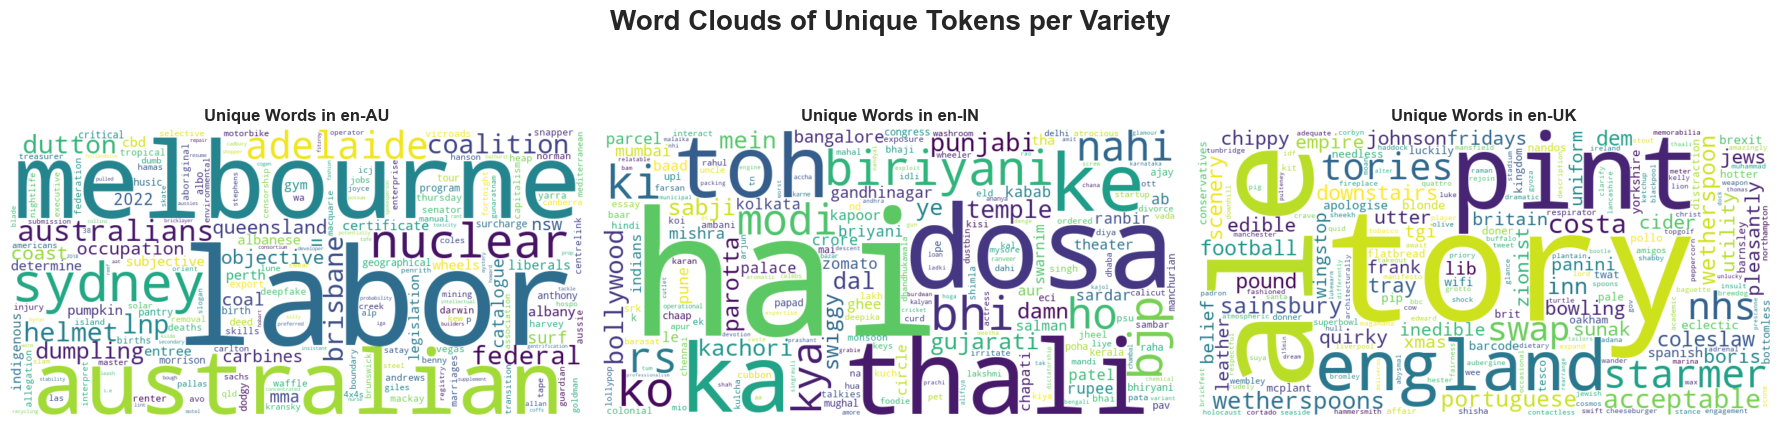

In [142]:
from wordcloud import WordCloud
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, variety in zip(axes, col_labels):
    word_freq = {word: vocabs[variety][word] for word in unique_words[variety]}
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Unique Words in {variety}", fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Word Clouds of Unique Tokens per Variety', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'unique_words_wordclouds.png'))
plt.show()